In [1]:
# In this notebook we will look at how not to intialize weight values

In [2]:
# Let's now load the necessary libaries and prepare the dataset for the cases

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Dense,Input

In [8]:
X,y = make_moons(
                    n_samples=250,
                    noise = 0.22,
                    random_state = 12
)

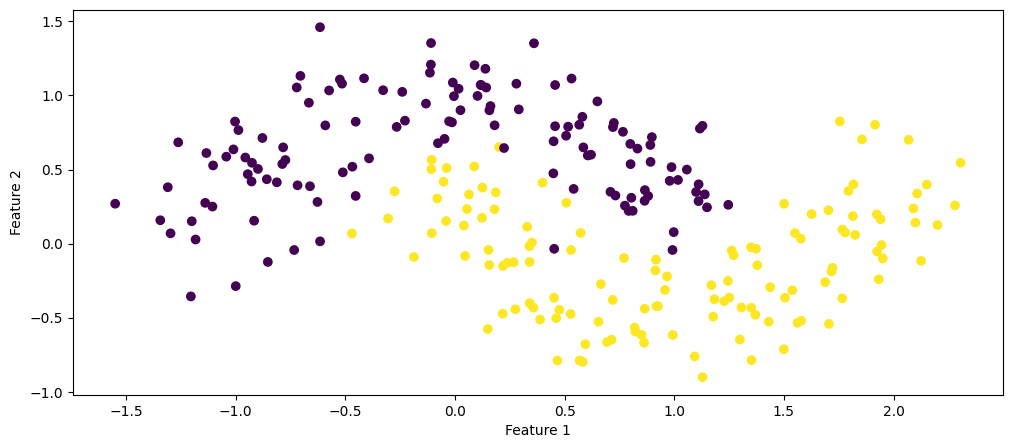

In [9]:
# Now lets plot this data to understand it better
plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
# Split the dataset 
X_train ,X_test ,y_train ,y_test = train_test_split(
                                                        X,y,
                                                        test_size = 0.2,
                                                        random_state = 9
)

# CASE 1 : Initialize with weights equal to 0

In [19]:
# FOR all the cases we will use a special function which does all the steps for us but we we only pass the activation function
# used for the hidden layers and the output layer 

def weight_initialization_zero(af_hidden,af_output,n_layers,neurons_per_layer,loss_function,metric_score):
    
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))

    for _ in range(n_layers):
        model.add(Dense(neurons_per_layer,activation=af_hidden))
    
    model.add(Dense(1,activation=af_output))

    print(model.summary())

    initial_weights = model.get_weights()

    zero_weights = [np.zeros_like(w) for w in initial_weights]
    model.set_weights(zero_weights)

    print(f'The initial model weights set to  : \n {model.get_weights()} \n ')

    model.compile(loss=loss_function,optimizer='adam',metrics=metric_score)

    history = model.fit( X,y,epochs=100,validation_data = (X_test,y_test),verbose=0)

    # Plot the loss across epochs
    print(f'The model weights after fitting are  : \n {model.get_weights()} \n ')

    print(f'The loss across epoch is   :  \n ')
    
    plt.figure(figsize=(15,5))
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f'The decision boundary made by the model :  \n ')

    plt.figure(figsize=(15,5))
    plot_decision_regions(X_test, y_test.ravel().astype(int), clf = model, legend=2)
    plt.show()



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32), array([0.], dtype=float32)] 
 
The model weights after fitt

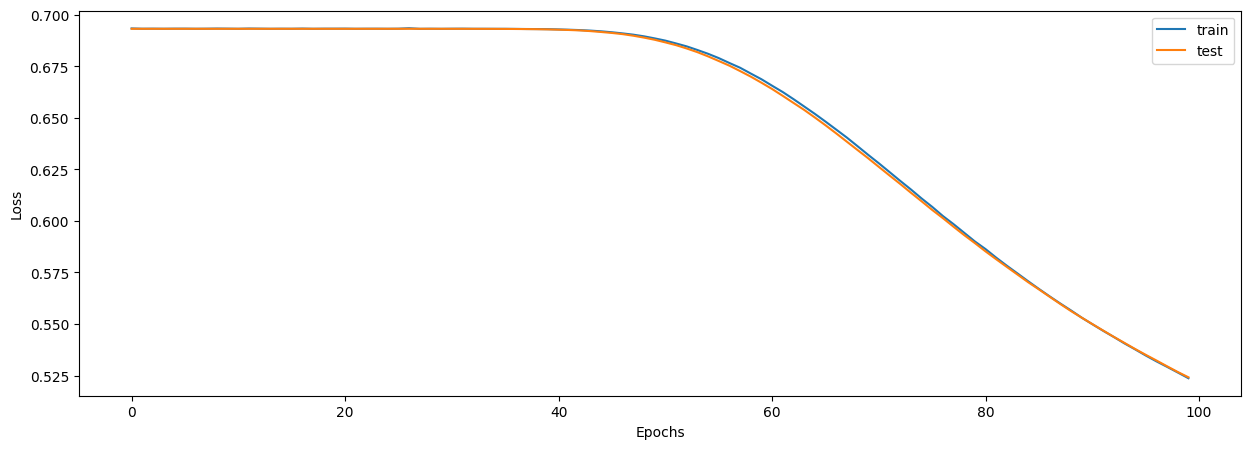

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step


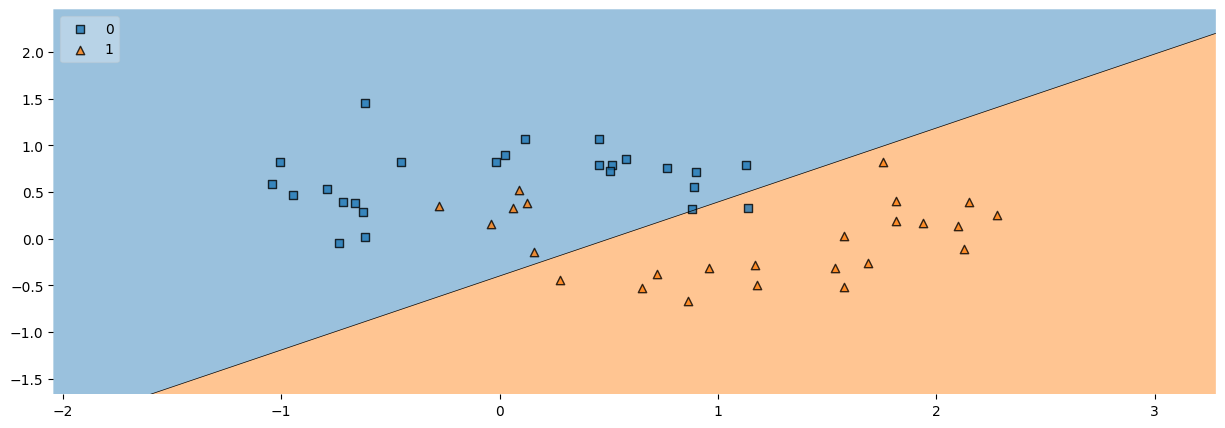

In [20]:
weight_initialization_zero(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'sigmoid',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [ ]:
'''
Mathematical Blind Spot: Initial zero-weights force \(\text{sigmoid}(0) = 0.5\), locking the initial loss at pure guesswork (0.693).
Extremely weak initial gradients trap the Adam optimizer on a flat plateau for nearly 45 epochs before it builds momentum.
Symmetric Collapse: Because every hidden neuron receives the exact same gradient,
   all 10 neurons update to the exact same final weights (e.g., 1.1136198)
10-neuron layer collapses into 1 functional neuron, breaking the model's ability to learn non-linear patterns.
'''

In [22]:
# Now we will use tanh as activation function

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32), array([0.], dtype=float32)] 
 
The model weights after fitt

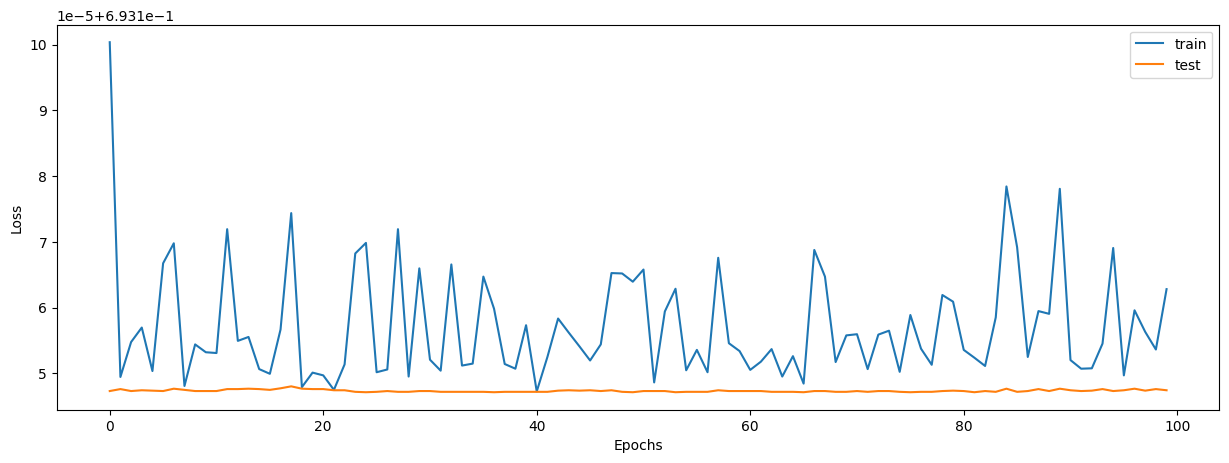

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 74s 3ms/step


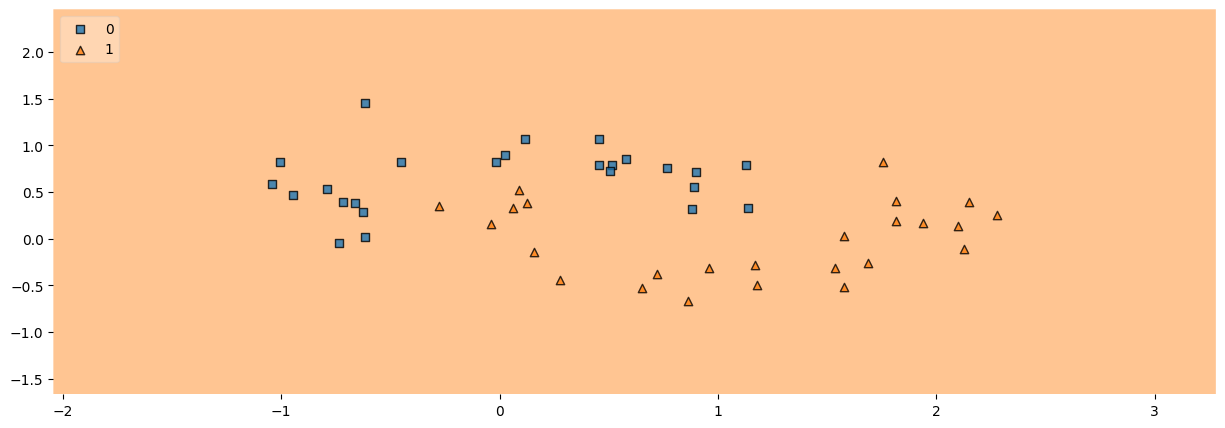

In [23]:
weight_initialization_zero(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'tanh',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [ ]:
'''
The Tanh / ReLU Failure Summary

    Absolute Gradient Death: Because (f(0) = 0), forward signals and backward gradients hit an absolute zero.
    Permanent Weight Paralysis: Hidden weights are completely unable to update, remaining frozen at 0.0 forever.
    Microscopic Micro-Ripples: Only the final output bias updates slightly, creating tiny deceptive ripples around 0.6931.
    Total Classification Blindness: The decision boundary collapses into a solid, single-color block with zero ability to separate classes

'''

In [26]:
# A similar result will be found when using relu , let's check it out 

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32), array([0.], dtype=float32)] 
 
The model weights after fitt

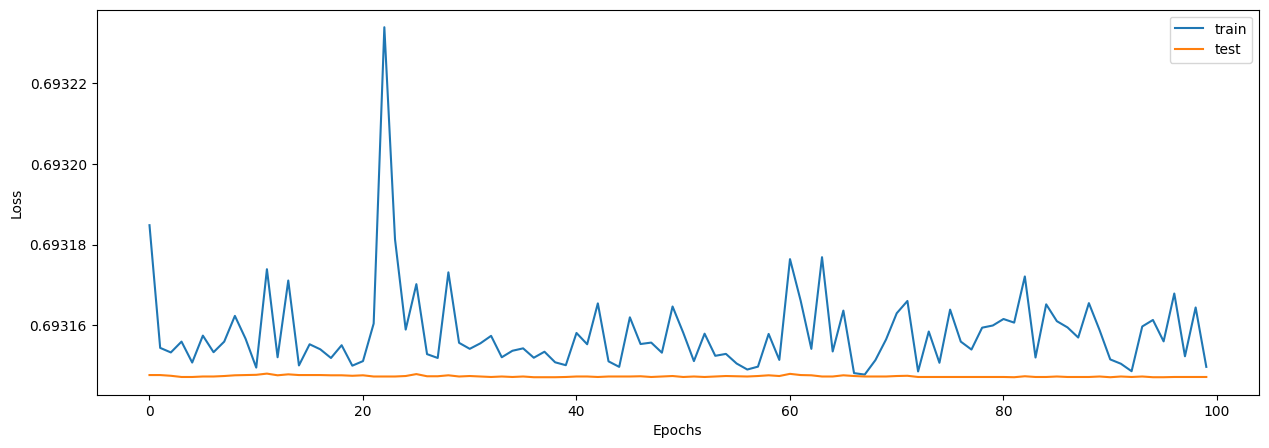

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step


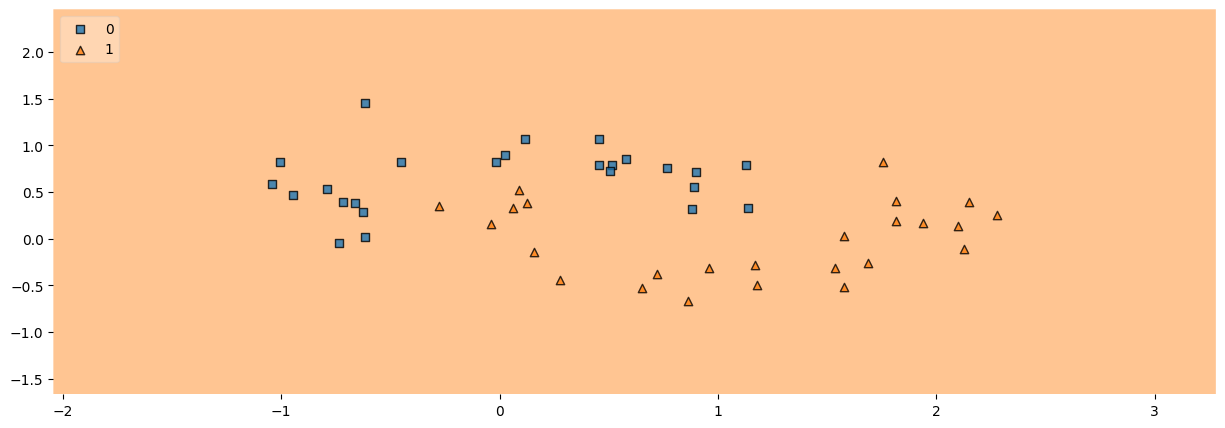

In [27]:
weight_initialization_zero(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'relu',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [28]:
# As expected similar to tanh

# CASE 1 : Initialize weights with a constant value k = 0.5

In [ ]:
# SAME FUNCTION but we initialize now with 0.5 

def weight_initialization_half(af_hidden,af_output,n_layers,neurons_per_layer,loss_function,metric_score):
    
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))

    for _ in range(n_layers):
        model.add(Dense(neurons_per_layer,activation=af_hidden))
    
    model.add(Dense(1,activation=af_output))

    print(model.summary())

    initial_weights = model.get_weights()

    half_weights = [np.ones_like(w)*0.5 for w in initial_weights]
    model.set_weights(half_weights)

    print(f'The initial model weights set to  : \n {model.get_weights()} \n ')

    model.compile(loss=loss_function,optimizer='adam',metrics=metric_score)

    history = model.fit( X,y,epochs=100,validation_data = (X_test,y_test),verbose=0)

    # Plot the loss across epochs
    print(f'The model weights after fitting are  : \n {model.get_weights()} \n ')

    print(f'The loss across epoch is   :  \n ')
    
    plt.figure(figsize=(15,5))
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f'The decision boundary made by the model :  \n ')

    plt.figure(figsize=(15,5))
    plot_decision_regions(X_test, y_test.ravel().astype(int), clf = model, legend=2)
    plt.show()



Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.

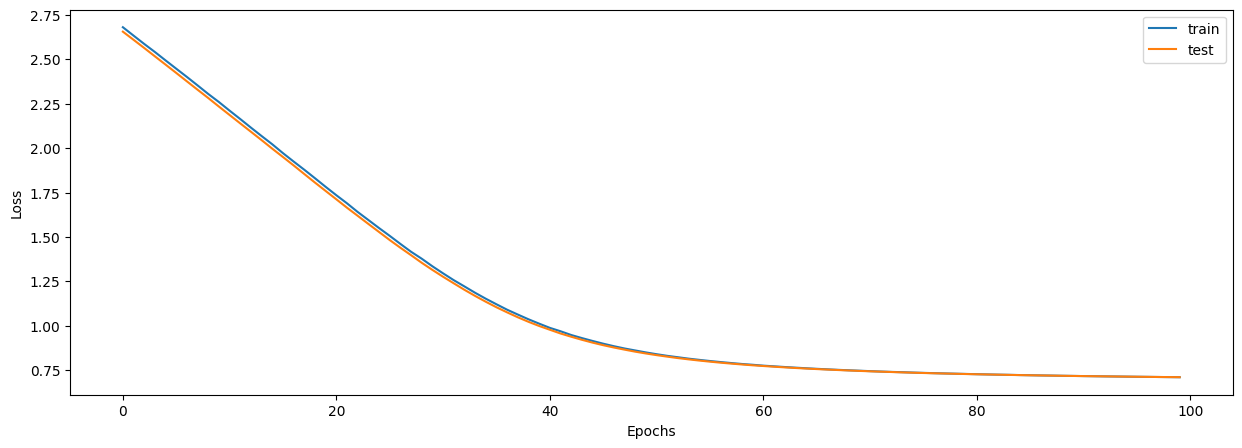

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 73s 3ms/step


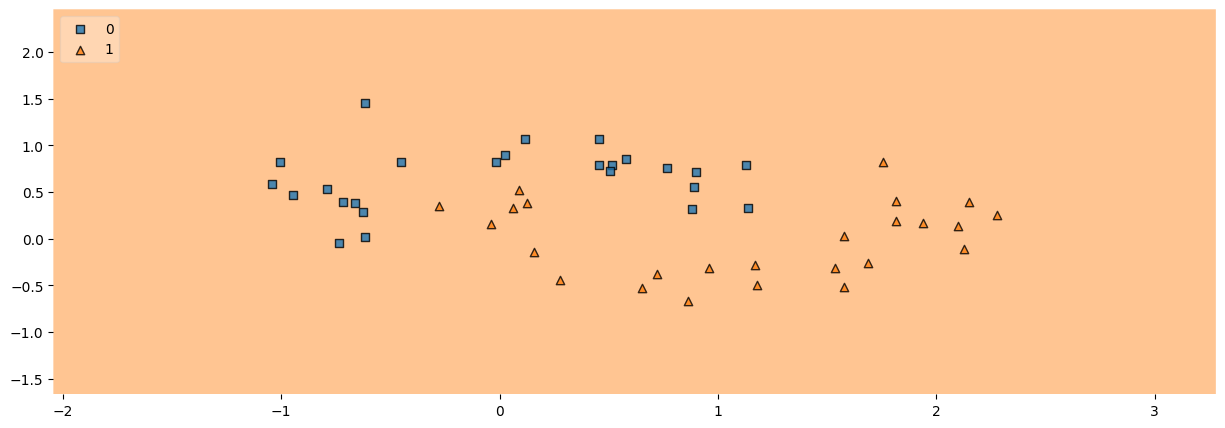

In [30]:
weight_initialization_half(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'sigmoid',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.

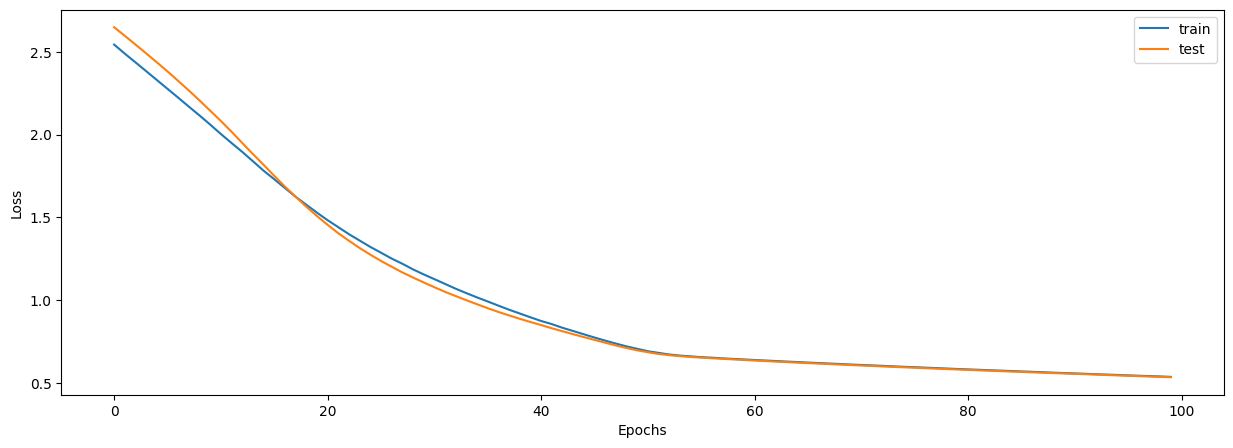

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 102s 4ms/step


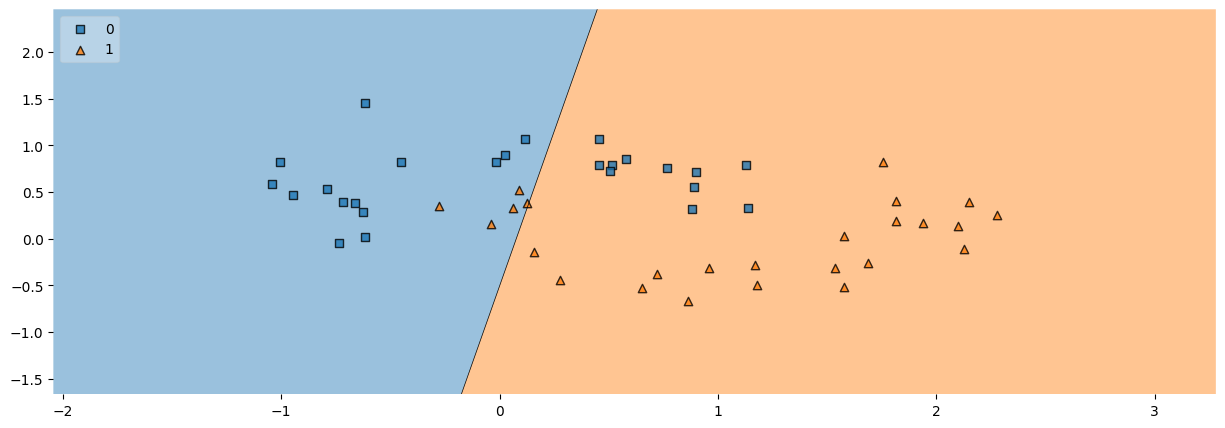

In [31]:
weight_initialization_half(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'tanh',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.

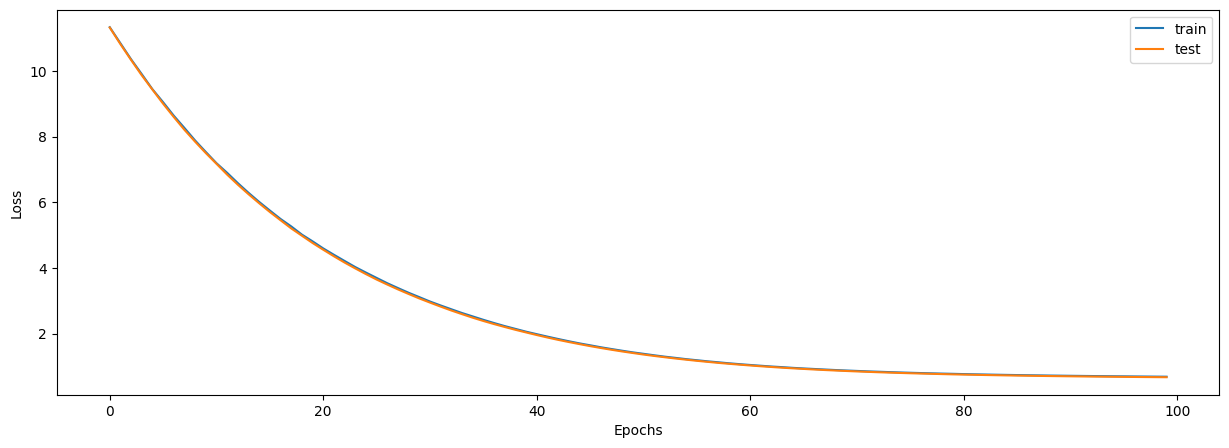

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 85s 4ms/step


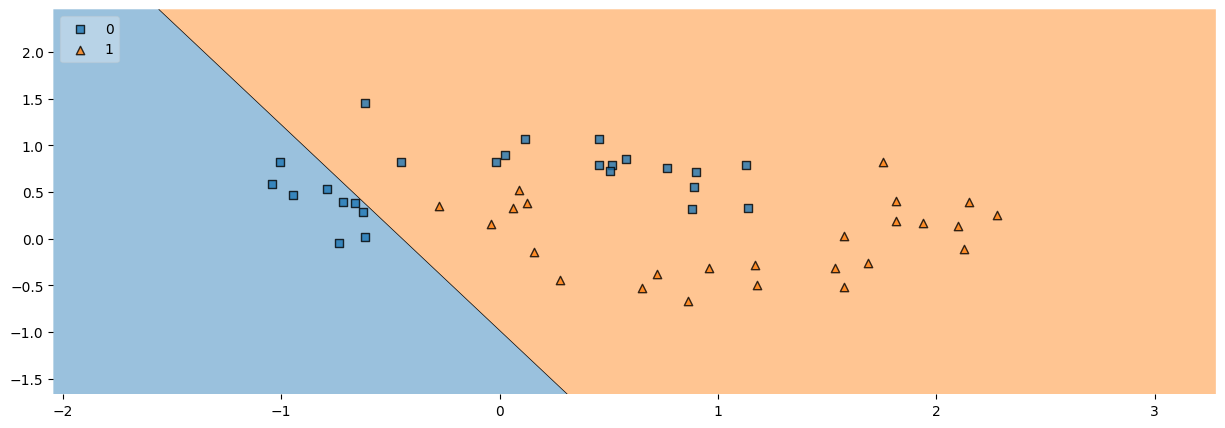

In [32]:
weight_initialization_half(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'relu',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

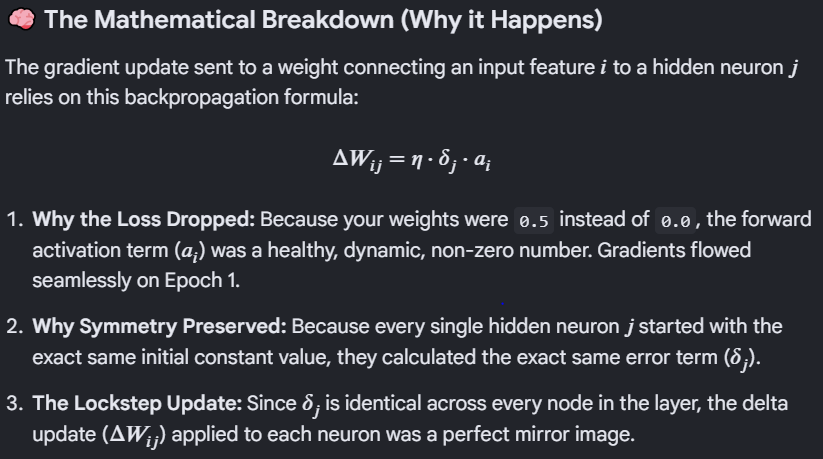

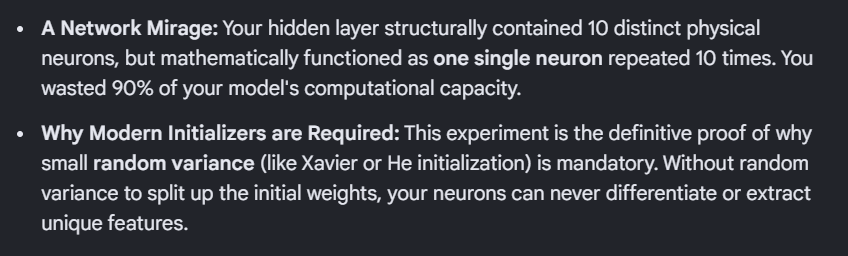